In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/European_Bank.csv')
df = df.drop(columns=['Year'])

df['AgeBand'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 92], labels=['18-30', '31-45', '46-60', '61+'])
df['HighBalance'] = (df['Balance'] > df['Balance'].median()).astype(int)

def classify_engagement(row):
    if row['IsActiveMember'] == 1:
        if row['NumOfProducts'] >= 2:
            return 'Active Engaged'
        else:
            return 'Active Low-Product'
    else:
        if row['HighBalance'] == 1:
            return 'Inactive High-Balance'
        else:
            return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeBand,HighBalance,EngagementProfile
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,31-45,0,Active Low-Product
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,31-45,0,Active Low-Product
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,31-45,1,Inactive High-Balance
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-45,0,Inactive Disengaged
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,31-45,1,Active Low-Product


                                ChurnRate  Count
BalanceQuartile IsActiveMember                  
Q1 (lowest)     0                0.184189   1227
                1                0.109976   1273
Q2              0                0.241852   1166
                1                0.104948   1334
Q3              0                0.342432   1209
                1                0.188226   1291
Q4 (highest)    0                0.304731   1247
                1                0.169194   1253


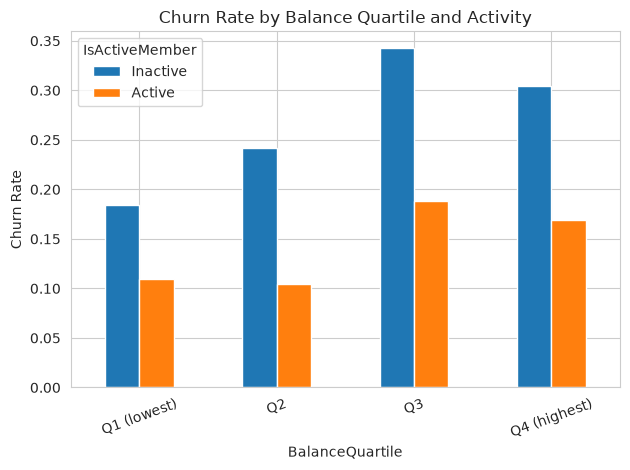

In [2]:
df['BalanceQuartile'] = pd.qcut(df['Balance'].rank(method='first'), 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

cross = df.groupby(['BalanceQuartile', 'IsActiveMember'], observed=True)['Exited'].agg(['mean', 'count'])
cross.columns = ['ChurnRate', 'Count']
print(cross)

pivot = df.pivot_table(index='BalanceQuartile', columns='IsActiveMember', values='Exited', aggfunc='mean', observed=True)
pivot.plot(kind='bar', title='Churn Rate by Balance Quartile and Activity', ylabel='Churn Rate')
plt.legend(title='IsActiveMember', labels=['Inactive', 'Active'])
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/figures/churn_balance_activity.png', dpi=150)
plt.show()

In [3]:
at_risk_premium = df[
    (df['IsActiveMember'] == 0) &
    (df['Balance'] > df['Balance'].quantile(0.75)) &
    (df['EstimatedSalary'] > df['EstimatedSalary'].quantile(0.75)) &
    (df['Exited'] == 0)
]

print(f"At-risk premium customers (live watchlist): {len(at_risk_premium)} ({len(at_risk_premium)/len(df)*100:.1f}% of base)")
print(f"Average balance: {at_risk_premium['Balance'].mean():.2f}")
print(f"Average salary: {at_risk_premium['EstimatedSalary'].mean():.2f}")
print(f"Geography split:\n{at_risk_premium['Geography'].value_counts(normalize=True).round(3) * 100}")

At-risk premium customers (live watchlist): 220 (2.2% of base)
Average balance: 148164.82
Average salary: 176746.23
Geography split:
Geography
France     42.3
Germany    41.4
Spain      16.4
Name: proportion, dtype: float64


In [4]:
mismatch = df[
    (df['EstimatedSalary'] > df['EstimatedSalary'].quantile(0.75)) &
    (df['Balance'] == 0)
]

print(f"High-salary, zero-balance mismatch customers: {len(mismatch)} ({len(mismatch)/len(df)*100:.1f}% of base)")
print(f"Churn rate in this group: {mismatch['Exited'].mean()*100:.1f}%")
print(f"% inactive: {(mismatch['IsActiveMember']==0).mean()*100:.1f}%")
print(f"\nOverall churn rate for reference: {df['Exited'].mean()*100:.1f}%")

High-salary, zero-balance mismatch customers: 891 (8.9% of base)
Churn rate in this group: 14.8%
% inactive: 49.2%

Overall churn rate for reference: 20.4%


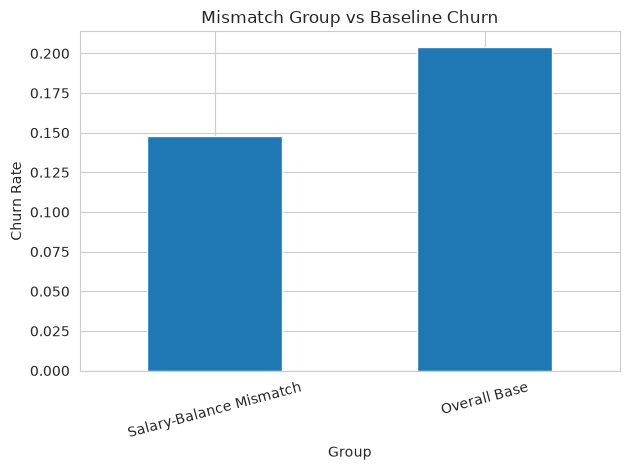

In [5]:
comparison = pd.DataFrame({
    'Group': ['Salary-Balance Mismatch', 'Overall Base'],
    'ChurnRate': [mismatch['Exited'].mean(), df['Exited'].mean()]
})

comparison.plot(x='Group', y='ChurnRate', kind='bar', legend=False, title='Mismatch Group vs Baseline Churn')
plt.ylabel('Churn Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/figures/mismatch_vs_baseline.png', dpi=150)
plt.show()

## Financial Commitment vs Engagement Summary

- Balance × activity: active members churn less than inactive members at every balance level (11.0-18.8% vs 18.4-34.2%) — engagement is protective regardless of wealth. Among inactive customers specifically, churn rises with balance from Q1 to Q3 (18.4% → 34.2%) before dipping slightly at Q4, reinforcing that high balance does not protect disengaged customers.
- At-risk premium watchlist (inactive, top-quartile balance and salary, not yet churned): 220 customers (2.2% of base), average balance €148,165, average salary €176,746. Nearly evenly split between France (42.3%) and Germany (41.4%) — less concentrated in Germany than earlier findings, making this a more geographically general risk group.
- Salary-balance mismatch (high salary, zero balance): 891 customers (8.9% of base), churn rate 14.8% — below the 20.4% baseline. This group reflects customers who use this bank for salary/transactions while banking savings elsewhere; the pattern is stable, not a churn risk.